# nbbench thermo-seq: Sequence similarity validation

Validate sequence similarity between train / test / val splits; compute **maximum sequence identity to other splits** per sample and visualize with histograms.

**Dependency**: `pip install biopython` is required.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Bio.Align import PairwiseAligner

# Reference CSVs in the same directory as this notebook
DATA_DIR = Path(".").resolve()
assert (DATA_DIR / "train.csv").exists(), f"train.csv not found in {DATA_DIR}"
print(f"Data directory: {DATA_DIR}")

Data directory: /data3/taihei/matsunaga-repos/nanobody-thermostability-sae/data/nbbench/thermo-seq


In [2]:
df_train = pd.read_csv(DATA_DIR / "train.csv")
df_test = pd.read_csv(DATA_DIR / "test.csv")
df_val = pd.read_csv(DATA_DIR / "val.csv")

seq_train = df_train["seq"].astype(str).tolist()
seq_test = df_test["seq"].astype(str).tolist()
seq_val = df_val["seq"].astype(str).tolist()

print(f"train: {len(seq_train)} sequences")
print(f"test:  {len(seq_test)} sequences")
print(f"val:   {len(seq_val)} sequences")
lens_train = [len(s) for s in seq_train]
lens_test = [len(s) for s in seq_test]
lens_val = [len(s) for s in seq_val]
print(f"train length: min={min(lens_train)}, max={max(lens_train)}, mean={np.mean(lens_train):.1f}")
print(f"test  length: min={min(lens_test)}, max={max(lens_test)}, mean={np.mean(lens_test):.1f}")
print(f"val   length: min={min(lens_val)}, max={max(lens_val)}, mean={np.mean(lens_val):.1f}")

train: 522 sequences
test:  147 sequences
val:   95 sequences
train length: min=111, max=151, mean=123.5
test  length: min=115, max=134, mean=123.7
val   length: min=113, max=136, mean=123.8


In [3]:
# Perform global alignment of two sequences; return identity = matches / alignment length.
# Alignment length includes gaps (conventional).
def sequence_identity(seq_a: str, seq_b: str, aligner: PairwiseAligner) -> float:
    if not seq_a or not seq_b:
        return 0.0
    alns = aligner.align(seq_a, seq_b)
    aln = next(iter(alns))
    # aligned length = number of aligned pairs (including gaps)
    aln_len = aln.length
    if aln_len == 0:
        return 0.0
    matches = sum(1 for i, j in zip(aln[0], aln[1]) if i == j)
    return matches / aln_len

# Global aligner (for protein; gap penalties default)
aligner = PairwiseAligner(mode="global", substitution_matrix=None)
# BLOSUM62 etc. can be used for protein; for identity only, match/mismatch is sufficient
aligner.match_score = 1
aligner.mismatch_score = 0
aligner.open_gap_score = -1
aligner.extend_gap_score = -0.5

In [4]:
def max_identity_to_other(query_seqs: list, target_seqs: list, aligner: PairwiseAligner) -> np.ndarray:
    """For each sequence in query_seqs, return the maximum identity to any sequence in target_seqs."""
    n = len(query_seqs)
    out = np.zeros(n)
    for i, q in enumerate(query_seqs):
        best = 0.0
        for t in target_seqs:
            id_ = sequence_identity(q, t, aligner)
            if id_ > best:
                best = id_
        out[i] = best
    return out

In [5]:
print("Computing max sequence identity between splits (this may take a few minutes)...")

max_train_to_test = max_identity_to_other(seq_train, seq_test, aligner)
max_train_to_val = max_identity_to_other(seq_train, seq_val, aligner)
max_test_to_train = max_identity_to_other(seq_test, seq_train, aligner)
max_test_to_val = max_identity_to_other(seq_test, seq_val, aligner)
max_val_to_train = max_identity_to_other(seq_val, seq_train, aligner)
max_val_to_test = max_identity_to_other(seq_val, seq_test, aligner)

results = {
    "train": {"to_test": max_train_to_test, "to_val": max_train_to_val},
    "test": {"to_train": max_test_to_train, "to_val": max_test_to_val},
    "val": {"to_train": max_val_to_train, "to_test": max_val_to_test},
}
print("Done.")

Computing max sequence identity between splits (this may take a few minutes)...
Done.


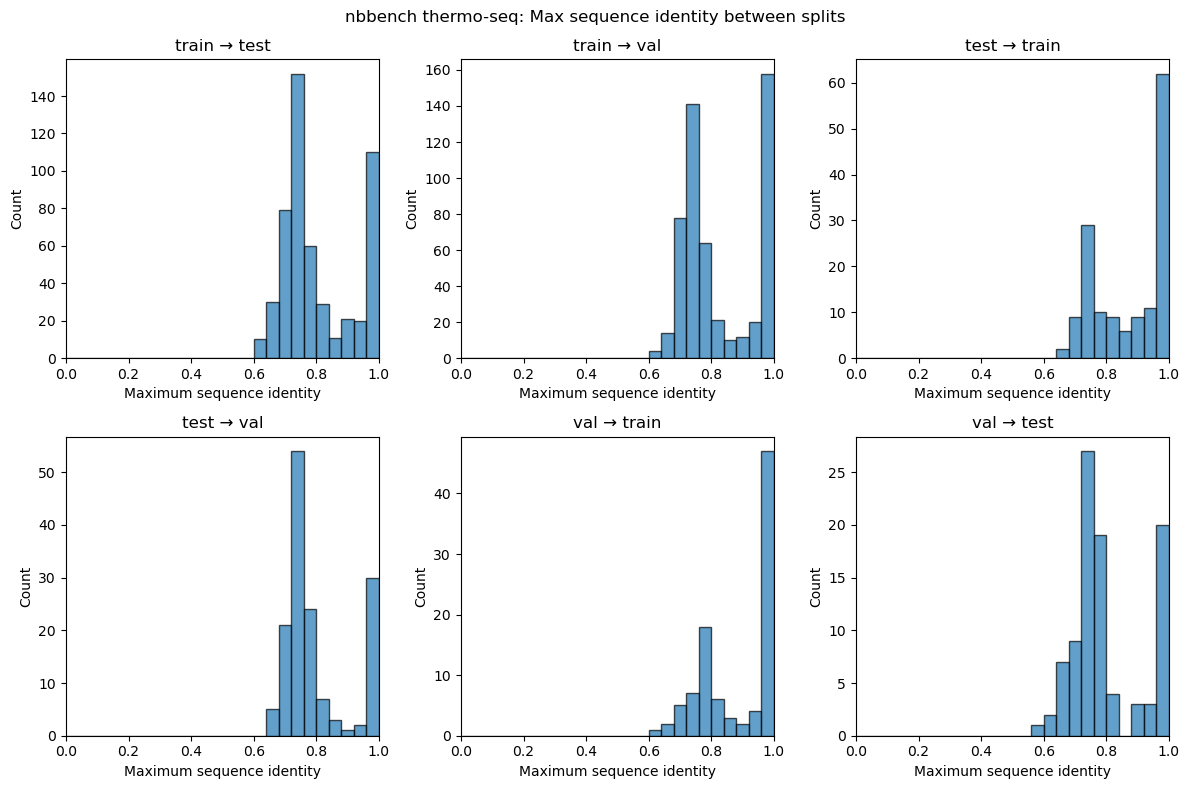

In [6]:
bins = np.linspace(0, 1, 26)  # 0, 0.04, ..., 1.0

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

pairs = [
    ("train → test", results["train"]["to_test"]),
    ("train → val", results["train"]["to_val"]),
    ("test → train", results["test"]["to_train"]),
    ("test → val", results["test"]["to_val"]),
    ("val → train", results["val"]["to_train"]),
    ("val → test", results["val"]["to_test"]),
]

for ax, (label, values) in zip(axes, pairs):
    ax.hist(values, bins=bins, edgecolor="black", alpha=0.7)
    ax.set_xlabel("Maximum sequence identity")
    ax.set_ylabel("Count")
    ax.set_title(label)
    ax.set_xlim(0, 1)

plt.suptitle("nbbench thermo-seq: Max sequence identity between splits", fontsize=12)
plt.tight_layout()
plt.show()

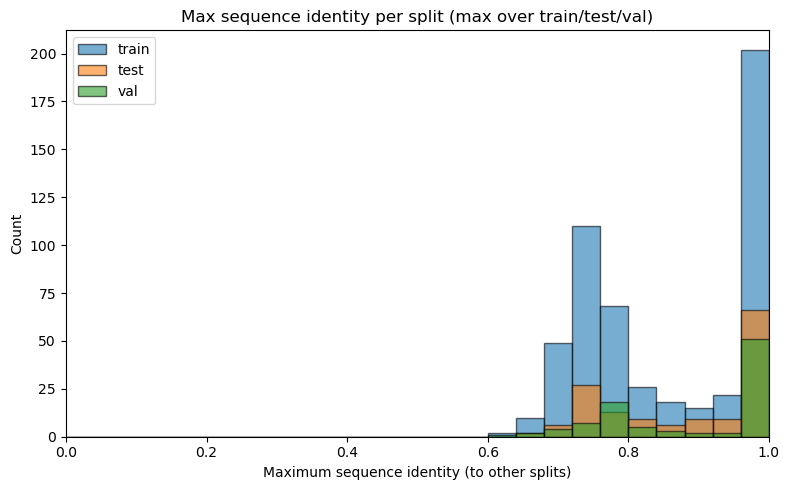

In [7]:
# Histogram: per sample, the maximum of (max identity to the other two splits)
max_train = np.maximum(results["train"]["to_test"], results["train"]["to_val"])
max_test = np.maximum(results["test"]["to_train"], results["test"]["to_val"])
max_val = np.maximum(results["val"]["to_train"], results["val"]["to_test"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(max_train, bins=bins, alpha=0.6, label="train", edgecolor="black")
ax.hist(max_test, bins=bins, alpha=0.6, label="test", edgecolor="black")
ax.hist(max_val, bins=bins, alpha=0.6, label="val", edgecolor="black")
ax.set_xlabel("Maximum sequence identity (to other splits)")
ax.set_ylabel("Count")
ax.set_title("Max sequence identity per split (max over train/test/val)")
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

In [8]:
def stats(arr):
    return {"mean": np.mean(arr), "max": np.max(arr), "n_gt_80": int(np.sum(arr > 0.8))}

print("=== Summary: max sequence identity between splits ===")
for label, arr in [
    ("train → test", results["train"]["to_test"]),
    ("train → val", results["train"]["to_val"]),
    ("test → train", results["test"]["to_train"]),
    ("test → val", results["test"]["to_val"]),
    ("val → train", results["val"]["to_train"]),
    ("val → test", results["val"]["to_test"]),
]:
    s = stats(arr)
    print(f"{label}: mean={s['mean']:.3f}, max={s['max']:.3f}, count > 80%: {s['n_gt_80']}")
print("\n(> 80% identity with other split may indicate potential data leakage.)")

=== Summary: max sequence identity between splits ===
train → test: mean=0.804, max=0.993, count > 80%: 191
train → val: mean=0.827, max=0.992, count > 80%: 215
test → train: mean=0.877, max=0.993, count > 80%: 95
test → val: mean=0.798, max=0.992, count > 80%: 40
val → train: mean=0.887, max=0.992, count > 80%: 60
val → test: mean=0.801, max=0.992, count > 80%: 29

(> 80% identity with other split may indicate potential data leakage.)


## Data resplit (maximum sequence identity ≤ 80%)

Combine train / val / test, check for duplicate sequences, then **reassign so that maximum sequence identity to other splits does not exceed 80%**. Target ratio is **train : val : test ≈ 70 : 10 : 20**.

Outputs are saved in the same directory as `train_split80.csv`, `val_split80.csv`, `test_split80.csv` (existing train/val/test.csv are not overwritten). You can rename these to train/val/test.csv as needed.

In [9]:
# Concatenate all splits and check for duplicate sequences (by seq)
df_all = pd.concat([
    df_train.assign(_split="train"),
    df_val.assign(_split="val"),
    df_test.assign(_split="test"),
], ignore_index=True)

n_total = len(df_all)
dup_mask = df_all.duplicated(subset=["seq"], keep="first")
n_dup = dup_mask.sum()
df_unique = df_all[~dup_mask].copy()
n_unique = len(df_unique)

print(f"Total: {n_total} rows")
print(f"Duplicate sequences (exact seq match): {n_dup} (after dedup: {n_unique})")
if n_dup > 0:
    print(df_all[dup_mask].groupby("_split").size())

合計: 764 行
配列の重複（seq 完全一致）: 0 件（削除後 764 件）


In [10]:
# Resplit: group by 80% similarity, then assign groups to train/val/test (considering Tm distribution and 70:10:20)
IDENTITY_THRESHOLD = 0.80
TARGET_TRAIN, TARGET_VAL, TARGET_TEST = 0.70, 0.10, 0.20
LARGE_GROUP_SIZE = 20
tm_col = "label"

seqs = df_unique["seq"].astype(str).tolist()
n = len(seqs)

def max_id_to_list(seq, lst):
    if not lst:
        return 0.0
    return max(sequence_identity(seq, s, aligner) for s in lst)

def max_id_group_to_list(group_seqs, lst):
    if not lst:
        return 0.0
    return max(max_id_to_list(g, lst) for g in group_seqs)

# --- Step 1: Group by 80% similarity (connected components) ---
print("Step 1: Computing connected components with edges where identity >= 80%...")
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

rows, cols = [], []
for i in range(n):
    for j in range(i + 1, n):
        if sequence_identity(seqs[i], seqs[j], aligner) >= IDENTITY_THRESHOLD:
            rows.extend([i, j])
            cols.extend([j, i])
adj = csr_matrix(([1] * len(rows), (rows, cols)), shape=(n, n))
n_comp, labels = connected_components(adj, directed=False)
groups = []
for c in range(n_comp):
    inds = np.where(labels == c)[0].tolist()
    groups.append((inds, len(inds)))
groups.sort(key=lambda x: -x[1])
print("  Number of groups: {}, max size: {}".format(len(groups), groups[0][1] if groups else 0))

# --- Step 2 & 3: Assign groups in descending size order (considering Tm distribution) ---
all_tms = df_unique[tm_col].dropna()
all_mean = all_tms.mean()
all_std = all_tms.std()
all_median = all_tms.median()
all_iqr = all_tms.quantile(0.75) - all_tms.quantile(0.25)
if all_std == 0 or np.isnan(all_std):
    all_std = 1e-8
if all_iqr == 0 or np.isnan(all_iqr):
    all_iqr = 1e-8

def dist_tm_to_all(tms_list):
    if not tms_list:
        return 0.0
    s = pd.Series(tms_list)
    m, sd = s.mean(), s.std()
    med = s.median()
    iqr = s.quantile(0.75) - s.quantile(0.25) if len(s) >= 2 else 0.0
    if np.isnan(sd): sd = 0.0
    if np.isnan(iqr): iqr = 0.0
    return (abs(m - all_mean) / (abs(all_mean) + 1e-8) + abs(sd - all_std) / (all_std + 1e-8) +
            abs(med - all_median) / (abs(all_median) + 1e-8) + abs(iqr - all_iqr) / (all_iqr + 1e-8))

target_train_n = int(round(n * TARGET_TRAIN))
target_val_n = int(round(n * TARGET_VAL))
target_test_n = n - target_train_n - target_val_n

train_idx, val_idx, test_idx = [], [], []
train_seqs, val_seqs, test_seqs = [], [], []
train_tms, val_tms, test_tms = [], [], []
group_to_split = {}

for group_indices, size in groups:
    group_seqs = [seqs[i] for i in group_indices]
    group_tms = [df_unique.iloc[i][tm_col] for i in group_indices]
    id_to_train = max_id_group_to_list(group_seqs, train_seqs)
    id_to_val = max_id_group_to_list(group_seqs, val_seqs)
    id_to_test = max_id_group_to_list(group_seqs, test_seqs)
    can_train = id_to_val <= IDENTITY_THRESHOLD and id_to_test <= IDENTITY_THRESHOLD
    can_val = id_to_train <= IDENTITY_THRESHOLD and id_to_test <= IDENTITY_THRESHOLD
    can_test = id_to_train <= IDENTITY_THRESHOLD and id_to_val <= IDENTITY_THRESHOLD

    candidates = []
    if can_train:
        candidates.append("train")
    if can_val:
        candidates.append("val")
    if can_test:
        candidates.append("test")

    if not candidates:
        continue

    if size > LARGE_GROUP_SIZE:
        if "train" in candidates and len(train_idx) + size <= target_train_n:
            chosen = "train"
        else:
            best = None
            best_dist = np.inf
            for spl in candidates:
                if spl == "train" and len(train_idx) + size > target_train_n:
                    continue
                if spl == "val" and len(val_idx) + size > target_val_n:
                    continue
                if spl == "test" and len(test_idx) + size > target_test_n:
                    continue
                tms_new = (train_tms + group_tms if spl == "train" else
                           val_tms + group_tms if spl == "val" else test_tms + group_tms)
                d = dist_tm_to_all(tms_new)
                if d < best_dist:
                    best_dist = d
                    best = spl
            chosen = best if best is not None else candidates[0]
    else:
        best = None
        best_dist = np.inf
        for spl in candidates:
            if spl == "train" and len(train_idx) + size > target_train_n:
                continue
            if spl == "val" and len(val_idx) + size > target_val_n:
                continue
            if spl == "test" and len(test_idx) + size > target_test_n:
                continue
            tms_new = (train_tms + group_tms if spl == "train" else
                       val_tms + group_tms if spl == "val" else test_tms + group_tms)
            d = dist_tm_to_all(tms_new)
            if d < best_dist:
                best_dist = d
                best = spl
        chosen = best if best is not None else candidates[0]

    if chosen == "train":
        train_idx.extend(group_indices)
        train_seqs.extend(group_seqs)
        train_tms.extend(group_tms)
    elif chosen == "val":
        val_idx.extend(group_indices)
        val_seqs.extend(group_seqs)
        val_tms.extend(group_tms)
    else:
        test_idx.extend(group_indices)
        test_seqs.extend(group_seqs)
        test_tms.extend(group_tms)

# --- Step 4: Move groups to approach 70:10:20 ratio ---
group_list = [g[0] for g in groups]
max_adjust_iters = 500
for _ in range(max_adjust_iters):
    n_train, n_val, n_test = len(train_idx), len(val_idx), len(test_idx)
    target_ratio = np.array([TARGET_TRAIN, TARGET_VAL, TARGET_TEST])
    current_ratio = np.array([n_train, n_val, n_test]) / (n_train + n_val + n_test)
    moved = False
    for g_indices in group_list:
        g_seqs = [seqs[i] for i in g_indices]
        g_size = len(g_indices)
        from_split = None
        if set(g_indices).issubset(set(train_idx)):
            from_split = "train"
        elif set(g_indices).issubset(set(val_idx)):
            from_split = "val"
        elif set(g_indices).issubset(set(test_idx)):
            from_split = "test"
        if from_split is None:
            continue
        to_candidates = []
        if from_split == "train" and n_train > target_train_n:
            if max_id_group_to_list(g_seqs, val_seqs) <= IDENTITY_THRESHOLD:
                to_candidates.append(("val", n_val, target_val_n))
            if max_id_group_to_list(g_seqs, test_seqs) <= IDENTITY_THRESHOLD:
                to_candidates.append(("test", n_test, target_test_n))
        elif from_split == "val" and n_val > target_val_n:
            if max_id_group_to_list(g_seqs, train_seqs) <= IDENTITY_THRESHOLD:
                to_candidates.append(("train", n_train, target_train_n))
            if max_id_group_to_list(g_seqs, test_seqs) <= IDENTITY_THRESHOLD:
                to_candidates.append(("test", n_test, target_test_n))
        elif from_split == "test" and n_test > target_test_n:
            if max_id_group_to_list(g_seqs, train_seqs) <= IDENTITY_THRESHOLD:
                to_candidates.append(("train", n_train, target_train_n))
            if max_id_group_to_list(g_seqs, val_seqs) <= IDENTITY_THRESHOLD:
                to_candidates.append(("val", n_val, target_val_n))
        if not to_candidates:
            continue
        to_split = min(to_candidates, key=lambda x: abs((x[1] + g_size) - x[2]))[0]
        # Move: remove from from_split, add to to_split
        if from_split == "train":
            for i in g_indices:
                train_idx.remove(i)
                train_seqs.remove(seqs[i])
                train_tms.remove(df_unique.iloc[i][tm_col])
        elif from_split == "val":
            for i in g_indices:
                val_idx.remove(i)
                val_seqs.remove(seqs[i])
                val_tms.remove(df_unique.iloc[i][tm_col])
        else:
            for i in g_indices:
                test_idx.remove(i)
                test_seqs.remove(seqs[i])
                test_tms.remove(df_unique.iloc[i][tm_col])
        if to_split == "train":
            train_idx.extend(g_indices)
            train_seqs.extend(g_seqs)
            train_tms.extend([df_unique.iloc[i][tm_col] for i in g_indices])
        elif to_split == "val":
            val_idx.extend(g_indices)
            val_seqs.extend(g_seqs)
            val_tms.extend([df_unique.iloc[i][tm_col] for i in g_indices])
        else:
            test_idx.extend(g_indices)
            test_seqs.extend(g_seqs)
            test_tms.extend([df_unique.iloc[i][tm_col] for i in g_indices])
        moved = True
        break
    if not moved:
        break

print("Resplit result: train={}, val={}, test={}".format(len(train_idx), len(val_idx), len(test_idx)))
print("Target: train~{}, val~{}, test~{}".format(target_train_n, target_val_n, target_test_n))
n_assigned = len(train_idx) + len(val_idx) + len(test_idx)
if n_assigned < n:
    print("Warning: {} samples were not assigned (no split could accept them under the 80% constraint).".format(n - n_assigned))

Step 1: 同一性>=80%の辺で連結成分を計算中...


/home/taihei/.conda/envs/esm/lib/python3.11/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


  グループ数: 288, 最大サイズ: 116
再分割結果: train=535, val=76, test=153
目標: train約535, val約76, test約153


In [11]:
# Build resplit DataFrames and save to CSV (with _split80 suffix, do not overwrite originals)
df_train_new = df_unique.iloc[train_idx].drop(columns=["_split"])
df_val_new = df_unique.iloc[val_idx].drop(columns=["_split"])
df_test_new = df_unique.iloc[test_idx].drop(columns=["_split"])

out_dir = DATA_DIR
df_train_new.to_csv(out_dir / "train_split80.csv", index=False)
df_val_new.to_csv(out_dir / "val_split80.csv", index=False)
df_test_new.to_csv(out_dir / "test_split80.csv", index=False)
print("Saved to: {}, {}, {}".format(out_dir / "train_split80.csv", out_dir / "val_split80.csv", out_dir / "test_split80.csv"))
print("Row counts: train={}, val={}, test={}".format(len(df_train_new), len(df_val_new), len(df_test_new)))

保存先: /data3/taihei/matsunaga-repos/nanobody-thermostability-sae/data/nbbench/thermo-seq/train_split80.csv, /data3/taihei/matsunaga-repos/nanobody-thermostability-sae/data/nbbench/thermo-seq/val_split80.csv, /data3/taihei/matsunaga-repos/nanobody-thermostability-sae/data/nbbench/thermo-seq/test_split80.csv
行数: train=535, val=76, test=153


In [12]:
# Verify max sequence identity after resplit (confirm all <= 80%)
seq_train_new = df_train_new["seq"].astype(str).tolist()
seq_val_new = df_val_new["seq"].astype(str).tolist()
seq_test_new = df_test_new["seq"].astype(str).tolist()

max_train_to_test_new = max_identity_to_other(seq_train_new, seq_test_new, aligner)
max_train_to_val_new = max_identity_to_other(seq_train_new, seq_val_new, aligner)
max_test_to_train_new = max_identity_to_other(seq_test_new, seq_train_new, aligner)
max_test_to_val_new = max_identity_to_other(seq_test_new, seq_val_new, aligner)
max_val_to_train_new = max_identity_to_other(seq_val_new, seq_train_new, aligner)
max_val_to_test_new = max_identity_to_other(seq_val_new, seq_test_new, aligner)

results_new = {
    "train": {"to_test": max_train_to_test_new, "to_val": max_train_to_val_new},
    "test": {"to_train": max_test_to_train_new, "to_val": max_test_to_val_new},
    "val": {"to_train": max_val_to_train_new, "to_test": max_val_to_test_new},
}

print("=== Max sequence identity after resplit (all should be <= 0.80) ===")
for label, arr in [
    ("train -> test", results_new["train"]["to_test"]),
    ("train -> val", results_new["train"]["to_val"]),
    ("test -> train", results_new["test"]["to_train"]),
    ("test -> val", results_new["test"]["to_val"]),
    ("val -> train", results_new["val"]["to_train"]),
    ("val -> test", results_new["val"]["to_test"]),
]:
    s = stats(arr)
    print("{}: mean={:.3f}, max={:.3f}, count > 80%: {}".format(label, s["mean"], s["max"], s["n_gt_80"]))

=== 再分割後の最大配列同一性（すべて <= 0.80 であること）===
train -> test: mean=0.720, max=0.798, count > 80%: 0
train -> val: mean=0.714, max=0.793, count > 80%: 0
test -> train: mean=0.748, max=0.798, count > 80%: 0
test -> val: mean=0.718, max=0.786, count > 80%: 0
val -> train: mean=0.748, max=0.793, count > 80%: 0
val -> test: mean=0.722, max=0.786, count > 80%: 0


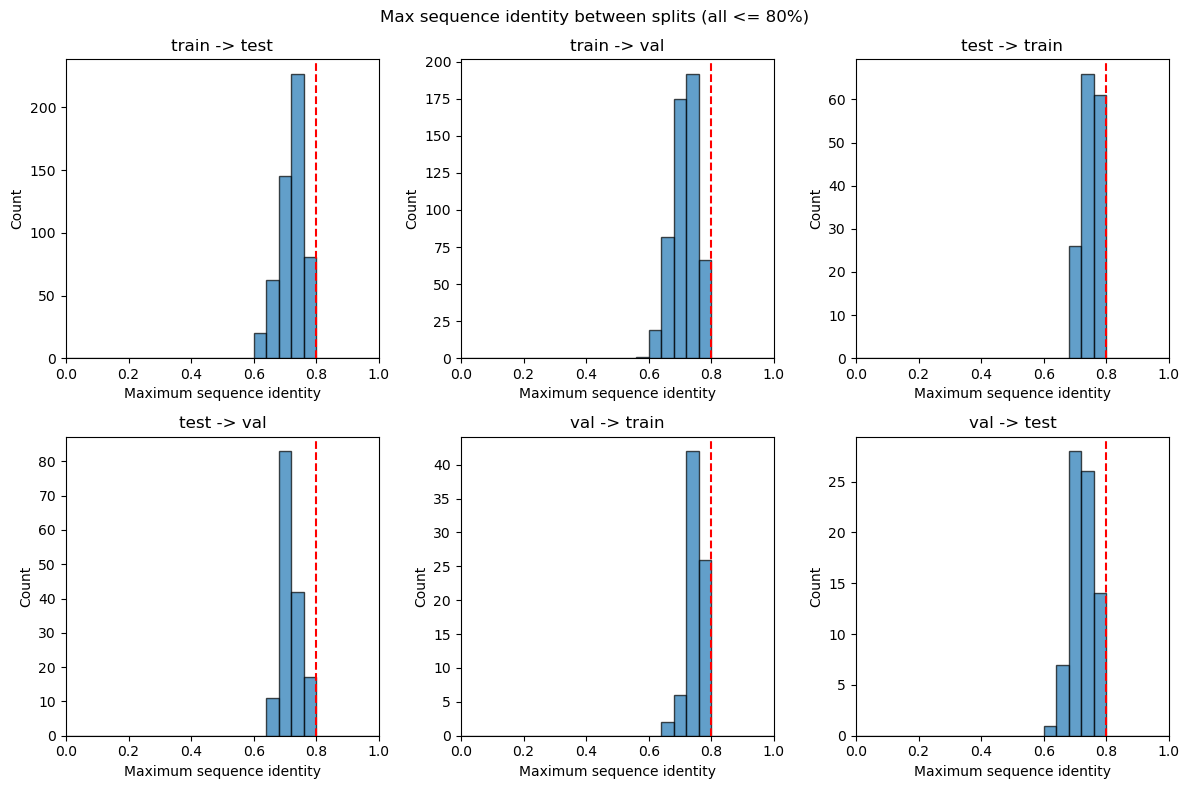

In [13]:
# Histogram of max sequence identity after resplit
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
pairs_new = [
    ("train -> test", results_new["train"]["to_test"]),
    ("train -> val", results_new["train"]["to_val"]),
    ("test -> train", results_new["test"]["to_train"]),
    ("test -> val", results_new["test"]["to_val"]),
    ("val -> train", results_new["val"]["to_train"]),
    ("val -> test", results_new["val"]["to_test"]),
]
for ax, (label, values) in zip(axes, pairs_new):
    ax.hist(values, bins=bins, edgecolor="black", alpha=0.7)
    ax.axvline(IDENTITY_THRESHOLD, color="red", linestyle="--", label="80%")
    ax.set_xlabel("Maximum sequence identity")
    ax.set_ylabel("Count")
    ax.set_title(label)
    ax.set_xlim(0, 1)
plt.suptitle("Max sequence identity between splits (all <= 80%)", fontsize=12)
plt.tight_layout()
plt.show()

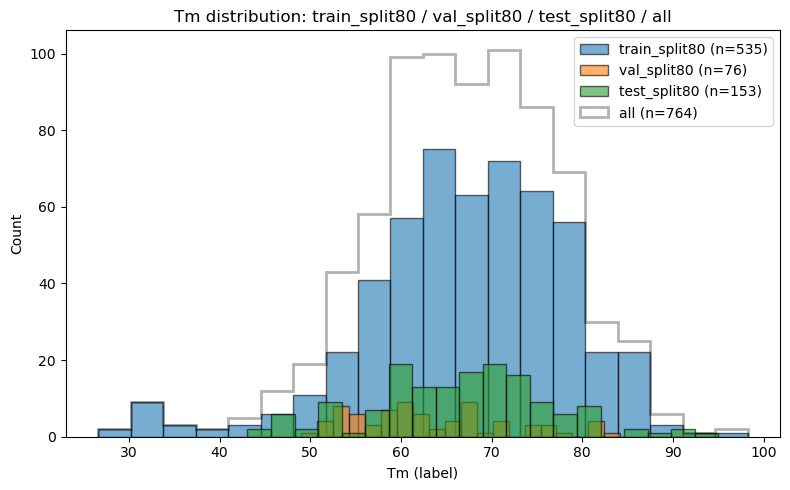

In [14]:
# Display Tm (label) distribution for train_split80, val_split80, test_split80, and all
tm_col = "label"  # Tm column in thermo-seq

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_train_new[tm_col].dropna(), bins=20, alpha=0.6, label="train_split80 (n={})".format(len(df_train_new)), edgecolor="black")
ax.hist(df_val_new[tm_col].dropna(), bins=20, alpha=0.6, label="val_split80 (n={})".format(len(df_val_new)), edgecolor="black")
ax.hist(df_test_new[tm_col].dropna(), bins=20, alpha=0.6, label="test_split80 (n={})".format(len(df_test_new)), edgecolor="black")
ax.hist(df_unique[tm_col].dropna(), bins=20, alpha=0.3, label="all (n={})".format(len(df_unique)), edgecolor="black", histtype="step", linewidth=2)
ax.set_xlabel("Tm (label)")
ax.set_ylabel("Count")
ax.set_title("Tm distribution: train_split80 / val_split80 / test_split80 / all")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1943635/3669787565.py:14: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:14: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:14: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:14: UserWarning: Glyph 20877 (\N{CJK UNIFIED IDEOGRAPH-518D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:14: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:14: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:14: UserWarning: Glyph 20840 (\N{CJK UN

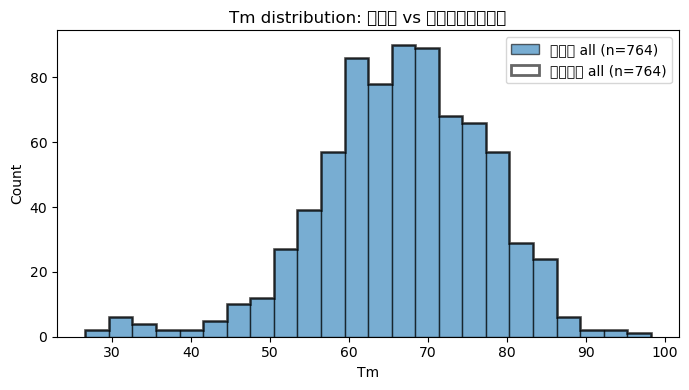

/tmp/ipykernel_1943635/3669787565.py:32: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:32: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:32: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:32: UserWarning: Glyph 20877 (\N{CJK UNIFIED IDEOGRAPH-518D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:32: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:32: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1943635/3669787565.py:32: UserWarning: Glyph 12503 (\N{KATAKANA LETTE

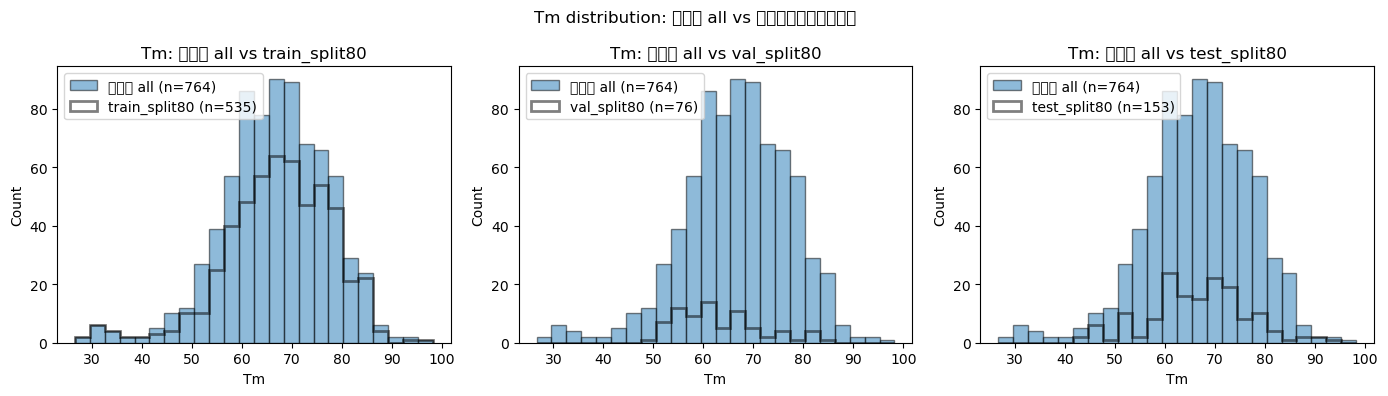

=== Tm 要約統計量（分割前 = all のみ、再分割後 = 各スプリット）===
分割前 all:  n=764, mean=66.77, std=10.61, median=67.00, IQR=14.22
再分割後 train_split80: n=535, mean=67.36, std=10.97, median=67.60, IQR=14.00
再分割後 val_split80: n=76, mean=63.15, std=8.61, median=61.50, IQR=11.47
再分割後 test_split80: n=153, mean=66.50, std=9.91, median=67.10, IQR=11.51
再分割後 all: n=764, mean=66.77, std=10.61, median=67.00, IQR=14.22


In [15]:
# Check whether Tm distribution is unchanged before vs after resplit
tm_col = "label"
df_resplit_all = pd.concat([df_train_new, df_val_new, df_test_new], ignore_index=True)
bins_tm = np.linspace(df_all[tm_col].min(), df_all[tm_col].max(), 25)

# 1) Overall distribution comparison
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_all[tm_col].dropna(), bins=bins_tm, alpha=0.6, label="Before resplit all (n={})".format(len(df_all)), edgecolor="black")
ax.hist(df_resplit_all[tm_col].dropna(), bins=bins_tm, alpha=0.6, label="After resplit all (n={})".format(len(df_resplit_all)), edgecolor="black", histtype="step", linewidth=2)
ax.set_xlabel("Tm")
ax.set_ylabel("Count")
ax.set_title("Tm distribution: before vs after resplit (overall)")
ax.legend()
plt.tight_layout()
plt.show()

# 2) Per-split comparison (before = all only; after = each split)
data_all = df_all[tm_col].dropna()
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label_new, data_new) in zip(axes2, [
    ("train_split80", df_train_new[tm_col]),
    ("val_split80", df_val_new[tm_col]),
    ("test_split80", df_test_new[tm_col]),
]):
    ax.hist(data_all, bins=bins_tm, alpha=0.5, label="Before resplit all (n={})".format(len(data_all)), edgecolor="black")
    ax.hist(data_new.dropna(), bins=bins_tm, alpha=0.5, label="{} (n={})".format(label_new, data_new.notna().sum()), edgecolor="black", histtype="step", linewidth=2)
    ax.set_xlabel("Tm")
    ax.set_ylabel("Count")
    ax.set_title("Tm: before resplit all vs {}".format(label_new))
    ax.legend()
plt.suptitle("Tm distribution: before resplit all vs after resplit by split", fontsize=12)
plt.tight_layout()
plt.show()

# 3) Summary statistics (comparison uses before-resplit all only): mean, std, median, IQR
def _iqr(s):
    return s.quantile(0.75) - s.quantile(0.25)

print("=== Tm summary statistics (before = all only; after = per split) ===")
o_all = df_all[tm_col].dropna()
print("Before resplit all:  n={}, mean={:.2f}, std={:.2f}, median={:.2f}, IQR={:.2f}".format(
    len(o_all), o_all.mean(), o_all.std(), o_all.median(), _iqr(o_all)))
for name_new, data_new in [
    ("train_split80", df_train_new[tm_col]),
    ("val_split80", df_val_new[tm_col]),
    ("test_split80", df_test_new[tm_col]),
]:
    n = data_new.dropna()
    print("After resplit {}: n={}, mean={:.2f}, std={:.2f}, median={:.2f}, IQR={:.2f}".format(
        name_new, len(n), n.mean(), n.std(), n.median(), _iqr(n)))
n_all = df_resplit_all[tm_col].dropna()
print("After resplit all: n={}, mean={:.2f}, std={:.2f}, median={:.2f}, IQR={:.2f}".format(
    len(n_all), n_all.mean(), n_all.std(), n_all.median(), _iqr(n_all)))